#   ANÁLISIS NLP DE PLANES DE GOBIERNO — MINERÍA EN PERÚ

Por: https://www.linkedin.com/in/mirko-smith/

OBJETIVO
--------
Identificar y comparar la orientación temática de los planes
de gobierno de cuatro partidos políticos peruanos respecto
al problema público de la minería ilegal, usando técnicas
de Procesamiento de Lenguaje Natural (NLP).

DATOS
-----
Se analizaron 97 oraciones extraídas de 4 planes de gobierno:
  • Plan Fuerza Popular        (30 oraciones)
  • Plan Alianza Para el Progreso (43 oraciones)
  • Plan País Para Todos       (19 oraciones)
  • Plan Renovación Popular    ( 5 oraciones)

METODOLOGÍA
-----------
1. PREPROCESAMIENTO
   Se limpiaron y normalizaron los textos: eliminación de
   stopwords, puntuación y tokens cortos. Se aplicó
   lematización con spaCy (es_core_news_sm) para reducir
   cada palabra a su forma base.

2. LDA (Latent Dirichlet Allocation)
   Se entrenó un modelo LDA con 4 topics sobre el corpus
   lematizado. El modelo identificó los siguientes temas
   latentes (coherencia c_v = 0.44):

     Topic 0 → Empleo y formalización minera
     Topic 1 → Pequeña minería e innovación productiva
     Topic 2 → Minería ilegal y zonas críticas
     Topic 3 → Infraestructura y conflictos locales

   Cada oración fue asignada al topic de mayor probabilidad.

3. ZERO-SHOT CLASSIFICATION
   Usando el modelo facebook/bart-large-mnli, cada oración
   fue clasificada en 12 etiquetas temáticas predefinidas
   (derivadas de los topics LDA y del contexto actual de
   minería ilegal en Perú) sin necesidad de datos etiquetados.

4. TF-IDF
   Se calculó la relevancia léxica de palabras y bigramas
   para cada plan de gobierno, permitiendo identificar el
   vocabulario distintivo de cada propuesta.

PRINCIPALES HALLAZGOS
---------------------
  • El topic dominante en el corpus es "Minería ilegal y
    zonas críticas" (Topic 2), presente en todos los planes.
  • Alianza Para el Progreso concentra el mayor volumen de
    propuestas, especialmente en formalización e infraestructura.
  • Renovación Popular, con solo 5 oraciones, muestra una
    propuesta poco desarrollada en materia minera.
  • El vocabulario TF-IDF revela que cada plan tiene un énfasis
    léxico distinto: FP enfatiza proyectos,
    APP enfatiza formalización y empleo, PPT enfatiza formalización y RP enfatiza medio ambiente.

PRINCIPALES LIMITANTES
-----------------------
Este tipo de análisis es poderoso, pero tiene restricciones importantes que impiden tomarlo como verdad absoluta:
1. El corpus es pequeño
97 oraciones distribuidas en 4 planes es un volumen muy reducido para NLP. Los modelos estadísticos como LDA necesitan grandes cantidades de texto para encontrar patrones robustos. Una coherencia de 0.44 (por debajo del umbral aceptable de 0.50) nos indica precisamente eso: los topics encontrados son orientativos, no definitivos.
2. Los planes de gobierno no son el discurso real
Un plan de gobierno es un documento político-técnico redactado para cumplir requisitos electorales. No necesariamente refleja lo que un partido hará en el poder, ni captura el discurso real de sus candidatos en campaña. Analizar el texto no equivale a analizar la intención política.
3. LDA no entiende el significado, solo la co-ocurrencia
LDA agrupa palabras que aparecen juntas, no palabras que significan lo mismo. Dos oraciones con el mismo significado pero vocabulario distinto pueden caer en topics diferentes. El modelo no comprende contexto, ironía, negaciones ni matices.
4. Zero-Shot tiene sesgo de idioma
El modelo facebook/bart-large-mnli fue entrenado predominantemente en inglés. Al aplicarlo sobre texto en español, su capacidad de inferencia semántica se reduce. Las etiquetas en español pueden no ser procesadas con la misma precisión que en inglés, lo que introduce ruido en la clasificación.
5. Las etiquetas temáticas las define el investigador
En Zero-Shot, tú decides qué categorías existen. Si una etiqueta importante no está en la lista, el modelo la ignorará por completo y asignará la oración a la categoría más cercana disponible, aunque no encaje bien. El análisis está condicionado por el conocimiento previo de quien lo diseña.
6. TF-IDF no captura semántica
Un TF-IDF alto indica que una palabra es distintiva de un plan, pero no dice nada sobre si esa propuesta es viable, coherente o prioritaria dentro del documento. Dos planes pueden usar la palabra "formalización" con significados operativos completamente distintos y el modelo no lo detectará.
7. El tamaño desigual de los planes distorsiona la comparación
Alianza Para el Progreso tiene 43 oraciones frente a las 5 de Renovación Popular. Comparar proporciones entre documentos tan distintos en volumen requiere cautela: un plan corto puede parecer poco comprometido simplemente porque tiene menos texto, no porque tenga menos propuestas.

¿Entonces para qué sirve?
Este análisis es válido como exploración inicial y sistemática del discurso político. Permite identificar patrones, comparar énfasis y generar hipótesis, pero debe complementarse con:
→ Análisis cualitativo del contenido
→ Revisión experta en política minera
→ Contraste con el discurso real de los candidatos
→ Corpus más amplio si se quieren conclusiones robustas
Los datos orientan. No reemplazan el juicio crítico.

HERRAMIENTAS UTILIZADAS
-----------------------
  Python · pandas · gensim · spaCy · transformers (HuggingFace)
  scikit-learn · matplotlib · seaborn · nltk


*NOTA. LOS TEXTOS DE LOS PLANES DE GOBIERNO FUERON EXTRAIDOS MANUALMENTE DE https://github.com/sorenriosdev/planes-gobierno-pe-2026/tree/master/data*
=============================================================

In [ ]:

# ## 1. Imports y Configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict
import string
import warnings
warnings.filterwarnings("ignore")

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize


# Gensim - LDA
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Scikit-learn - TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# HuggingFace - Zero-Shot
from transformers import pipeline

# Visualización adicional
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("WordCloud no disponible. Instala con: pip install wordcloud")

# Descargar recursos NLTK
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

WordCloud no disponible. Instala con: pip install wordcloud


True

In [108]:
CONFIG = {
    # LDA
    "num_topics": 4,          # Número de temas a extraer
    "lda_passes": 15,         # Épocas de entrenamiento LDA
    "lda_iterations": 100,
    "random_state": 42,

    # Zero-Shot
    "zs_model": "facebook/bart-large-mnli",  # Modelo zero-shot (inglés/multilingüe)
    # Alternativa en español: "typeform/distilbart-mnli-12-3"
    # Alternativa multilingüe: "joeddav/xlm-roberta-large-xnli"
    "zs_batch_size": 8,

    # TF-IDF
    "tfidf_max_features": 5000,
    "tfidf_ngram_range": (1, 2),    # Unigramas y bigramas
    "tfidf_min_df": 2,             # Filtrar términos muy raros
}


In [109]:
planes_gobierno = {
    "Plan_FuerzaPopular": """
        Infraestructura y competitividad minera

Impulso de APP y Obras por Impuestos para infraestructura en áreas vinculadas a proyectos mineros.

Ejecución del Plan Nacional de Servicios e Infraestructura Logística de Transporte al 2032, priorizando corredores viales y ferroviarios para conectar proyectos mineros altoandinos con puertos y mercados.

Ampliación de la red de transmisión eléctrica moderna en regiones mineras estratégicas.

Promoción de la instalación de plantas de fundición y procesamiento para dar valor agregado.

Impulso de la participación de proveedores locales y MYPEs en la cadena minera, con incentivos tributarios y no tributarios a empresas que contraten servicios regionales.

Modernización, innovación e integración productiva

Modernización de la Ley General de Minería para evitar la especulación mediante plazos obligatorios de exploración y producción, establecer un fast track para proyectos estratégicos, crear incentivos tributarios a la reinversión y un régimen diferenciado para la minería artesanal y de pequeña escala con apoyo técnico y acceso al crédito formal.

Creación de un Fondo Nacional de Innovación Minera para la minería artesanal y de pequeña escala, con incentivos tributarios para tecnologías de automatización, trazabilidad y reducción de impactos ambientales.

40

Creación de un Fondo de Garantías Estatales para la Minería Artesanal y de Pequeña Escala, destinado a respaldar operaciones de crédito y facilitar el acceso al financiamiento formal, reduciendo el riesgo para las entidades financieras y promoviendo inversión productiva responsable.

Establecimiento de alianzas con CITE Mineros y universidades para transferencia tecnológica en MAPE, mediana y gran minería.

Financiamiento de la implementación de monitoreo ambiental en tiempo real en operaciones de pequeña y mediana minería.

Culminación de la implementación nacional del SIPMMA (Sistema Interoperable para la Pequeña Minería y Minería Artesanal) para trazabilidad de insumos y minerales.

Digitalización de todos los trámites mineros a través de una Ventanilla Única Minera Electrónica con Inteligencia Artificial que sea interoperable con SUNAT, ANA y gobiernos regionales.

Difusión del potencial minero sostenible del Perú en foros internacionales, como estrategia de atracción de inversión responsable.

Sostenibilidad, orden y desarrollo territorial

Establecimiento de comandos mixtos PNP - FF.AA. - Fiscalía - SUNAT en zonas críticas para enfrentar minería ilegal y crimen organizado.

Exigencia de la remediación de pasivos ambientales, priorizando cuencas altoandinas y zonas críticas.

Mejoramiento de los estándares de seguridad ocupacional, con metas para reducir accidentes fatales.

Implementación del Canon para el Pueblo: hasta el 40% del canon directamente redistribuido a la población de la zona de extracción, con control comunitario.

2.2.3. Primeros 100 días

Aprobación de un paquete de APP y Obras por Impuestos para obras viales, ferroviarias y eléctricas que conecten corredores mineros estratégicos.

Publicación del Plan Nacional de Remediación de Pasivos Ambientales, priorizando cuencas altoandinas con riesgo social o ecológico.

Creación de comandos mixtos PNP–FF.AA.–Fiscalía–SUNAT para control de minería ilegal y crimen organizado en zonas críticas.

2.2.4. Principales metas e indicadores

TEMA	META AL 2031	INDICADOR
Infraestructura y
competitividad
minera.	Conectar al menos el 80% de los
principales proyectos mineros a
corredores
logísticos
pavimentados,
ferroviarios
o
portuarios,
reduciendo
costos	Porcentaje
de
proyectos
mineros
conectados
a
41

Col1	logísticos y mejorando la
competitividad.	corredores logísticos
pavimentados.
Modernización,
innovación e
integración
productiva.	Integrar al 100% de los operadores
MAPE
activos
al
SIPMMA,
garantizando trazabilidad técnica,
ambiental y comercial.	Porcentaje
de
operaciones
MAPE
registradas
e
interoperables
en
el
SIPMMA.
Sostenibilidad, orden
y desarrollo
territorial.	Reducir en 40% los accidentes
fatales y erradicar al menos el 50%
de la minería ilegal en zonas
críticas,
priorizando
seguridad,
fiscalización
y
remediación
ambiental.	Porcentaje
de
operaciones
ilegales
erradicadas en zonas
críticas.
    """,

    "Plan_RenovacionPopular": """
Deficiente
participación
nacional
en
la
modernización de
la minería	Impulsaremos la inversión en
tecnología y procedimientos
de última generación para la
minería, con la finalidad de
contar con una industria
moderna, limpia y cuidadosa
del
medio
ambiente.
Impulsaremos
la
investigación geológica que
permita la explotación de
nuevos yacimientos.
Adicionalmente
a
ello,
fomentaremos procesos que
den un mayor valor agregado
a nuestras materias primas,
con la finalidad de aumentar
la exportación de productos
terminados.	La
falta
de
información
sobre
la
exploración
minera
en
aquellas zonas
que
dependen
de
la
agricultura
ha
generado
una
desconfianza en
los habitantes.	Promoveremos
la
modernización de
la
minería
con
respeto al Medio
Ambiente
y
compatible con la
Agricultura.
    """,

    "Plan_PaisParaTodos": """
Equipo de Plan de Gobierno

Cerrar brechas de capital humano e impulsar innovación aplicada para crear empleo formal y productividad, con foco en jóvenes y territorios rezagados.

Formación técnica y superior alineada a sectores priorizados del Plan Crecer Productivo, articulando universidades, institutos, CITEs, sector privado y cooperación internacional

Inserción laboral juvenil: formación dual, certificación de competencias y prácticas en empresas.

I+D aplicada en territorio: red nacional de CITEs para pilotos, transferencia tecnológica y escalamiento productivo.

Becas y formación técnica territorial vinculadas a Portafolios Productivos Regionales y demanda real del mercado.

38

Participación de sectores estratégicos no primarios en el PBI.

Empleo formal generado en minería, agroexportación, turismo y sectores asociados.

Exportaciones no tradicionales, agroindustriales y de servicios modernos.

Productividad sectorial.

Indicadores de sostenibilidad (eficiencia energética,

Sectores estratégicos como motores de crecimiento:

Concentración productiva y exportadora: dependencia de primarios expone a choques externos y limita crecimiento sostenido.

Bajo valor agregado y encadenamientos débiles incluso en minería, agroexportación y turismo.

Subaprovechamiento de sectores intensivos en empleo territorial (turismo, cultura y economía del cuidado), hoy con alta informalidad y baja productividad.

Rezago en energías limpias y servicios intensivos en conocimiento (software, servicios digitales, ingeniería, diseño e industrias creativas) que generan empleo calificado y competitividad de largo plazo.

Equipo de Plan de Gobierno

Convertir sectores con potencial —minería sostenible, agroexportación moderna y turismo productivo— en motores de crecimiento y empleo formal: más valor agregado, más encadenamientos y transición verde.

Minería sostenible con proveedores: encadenamientos mineros y metalmecánicos; CITEs y mesas ejecutivas para innovación, estándares y cumplimiento ambiental; trazabilidad y eficiencia energética para reducir conflictos y subir productividad.

Agroexportación con transformación: más valor agregado, certificaciones y tecnología; pequeños productores conectados a cadenas con asistencia, financiamiento y asociatividad; agroindustria alineada a portafolios regionales.

Turismo productivo y sostenible: corredores turísticos que integren cultura, gastronomía y economías locales; formalización progresiva, capacitación y digitalización; empleo formal femenino y juvenil; industrias creativas como sector productivo con financiamiento vía COFIDE y fondos concursables.

Servicios modernos y economía del conocimiento: impulsar servicios digitales e industrias creativas como nuevos motores de crecimiento; integrar transición energética y economía verde como ventaja competitiva.
    """,

    "Plan_AlianzaParaElProgreso": """
¿Cuál es la situación actual?

La minería artesanal y de pequeña escala (MAPE) emplea a cientos de miles de personas, pero opera mayoritariamente en la informalidad, según datos del MINEM sólo el 2,4% están formalizados. Entre la informalidad y la ilegalidad se mueven cerca de 12,000 mil millones de soles anuales y el Estado deja de recaudar aproximadamente 7,800 millones. Los procesos de formalización han sido fragmentados, lentos y poco efectivos. La informalidad minera genera degradación ambiental, uso indiscriminado de mercurio, evasión fiscal, economías ilegales y conflictos sociales, afectando especialmente a la Amazonía y zonas altoandinas.

Estrategia:

Transformar la minería artesanal y de pequeña escala en una actividad formal, sostenible, segura y generadora de ingresos dignos, convirtiéndose en el motor del desarrollo regional complementado a la gran minería. (Minería para todos) [86] .

86 Estrategia alineada al Plan Estratégico de Desarrollo Nacional al 2050. Objetivo Nacional ON3: Elevar los niveles de competitividad y productividad con empleo decente y en base al aprovechamiento sostenible de los recursos, el capital humano, el uso intensivo de la ciencia y tecnología, y la transformación digital del país. Objetivo Específico O.E. 3.3: Elevar los niveles de competitividad y productividad de los sectores económicos, en base a la diversificación productiva, generación de valor agregado y la innovación tecnológica dentro de todos los sectores productivos, en el marco de una economía verde y baja en carbono y con el aprovechamiento de las tecnologías emergentes.

112

Actividades a desarrollar:

Rediseñar integralmente el proceso de formalización minera, simplificando trámites, estableciendo plazos claros y diferenciando territorios y tipologías de mineros.

Crear Centros Regionales de Formalización Minera, que integren asistencia técnica, ambiental, legal y financiera.

Facilitar el acceso a tecnología limpia, financiamiento y mercados formales para los pequeños mineros formalizados.

Fortalecer la interdicción focalizada contra la minería ilegal, articulando acciones del Estado con alternativas productivas reales.

Regulación y control de los insumos críticos que son parte de la actividad informal e ilegal.

Regulación, control y formalización de los diferentes eslabones de la cadena de producción y comercialización del oro.

Revisar la duplicidad, sobreposición de pequeñas y medianas concesiones.

Crear un fondo para la regeneración de las áreas degradadas.

Crear un sistema de registro de comercializadores y procesadores de oro.

Indicadores y Metas:

2.1. Incremento sostenido del número de mineros formalizados, la meta es llegar al 50% de formalización. Actualmente sólo están formalizados el 2,4%

2.2. Reducción de áreas degradadas por minería ilegal en 20% en coordinación con MINAM. Actualmente hay 100,000 Has degradas

2.3. Disminución del número de conflictos socioambientales asociados a la MAPE. Existe conflictos en las 24 regiones, más de 280 conflictos latentes.

2.4. Promover las compras certificadas de la gran minería a pequeños productores provengan de operadores formalizados y regulados. 100% de compra de oro certificado. Actualmente no existe.

Problema 3. Gran minería con bajo nivel de encadenamientos productivos y poco valor agregado.

¿Cuál es la situación actual?

La gran minería es uno de los principales motores de exportaciones e ingresos fiscales del país, aporta con el 8% del PBI y el 60% de la recaudación fiscal, sin embargo, su impacto en el desarrollo productivo nacional es limitado. Predomina la exportación de concentrados y minerales sin mayor transformación, con escasos encadenamientos industriales, tecnológicos y de servicios locales. Esto reduce el potencial de empleo de calidad, innovación y diversificación productiva, llegando así sólo a generar 276,458 empleos directos para el 2025.

Persisten pasivos ambientales graves que no se han remediado, afectando la salud, el medio ambiente y la calidad de vida de las comunidades cercanas a zonas mineras. La falta de infraestructura básica y servicios en estas regiones limita las oportunidades de desarrollo local, mientras que la inversión pública y privada no siempre está alineada con las necesidades y el desarrollo territoriales, generando conflictos sociales.

113

Estrategia:

Aprovechar la gran minería como plataforma para la industrialización, la innovación y el desarrollo de cadenas de valor nacionales y regionales [87] .

Actividades a desarrollar:

Promover clústeres minero-industriales regionales, integrando metalurgia, manufactura, servicios especializados, logística y tecnología.

Incentivar la inversión en plantas de procesamiento, refinación y transformación de minerales, bajo criterios de competitividad y sostenibilidad.

Fortalecer el contenido local, impulsando proveedores nacionales, MIPYMES y servicios tecnológicos vinculados a la minería.

Articular minería, ciencia y tecnología, promoviendo investigación aplicada, formación técnica especializada y transferencia tecnológica.

Indicadores y metas:

3.1. Incremento del valor agregado minero en el PBI en 15%. Actualmente se encuentra en 10%.

3.2. Porcentaje de crecimiento del número de proveedores locales certificados. Meta del 100% de crecimiento. Actualmente es 0 no existe certificación.

3.3. Crecimiento del empleo calificado vinculado al sector minero, en 20%. Actualmente se encuentra en 276, 458 empleos a diciembre.

Problema 4. Gobernanza sectorial fragmentada y débil presencia del Estado en el territorio.
""",

"Plan_PaisParaTodos": """
Fortalecimiento Integral del Desarrollo Minero

El Perú tiene más de 60 proyectos en espera de poder entrar en fases de explotación involucrando más de US$ 60 mil millones en materia de inversiones. Se apoyará decididamente la concreción de este importante portafolio de inversiones mineras y a todas aquellas que se quieran sumar. Viabilizar este portafolio no sólo le añadiría al PBI dos puntos porcentuales adicionales de crecimiento anual sostenido, sino que además generaría un círculo virtuoso en materia de continuar con las exploraciones y seguir descubriendo más vetas de mineral.

Viabilizar este gran potencial demanda una ardua tarea, ya que el país no tiene un problema de recursos, sino de institucionalidad, permisos y articulación territorial. Resolverlo multiplica inversión, empleo formal y encadenamientos.

Medidas: Ventanilla única digital minera, reforma normativa integral, sistema de regulación ambiental bajo enfoque de “Huella Ambiental”, agilización de la transición exploración–producción, Plan Nacional de Exploración Minera, régimen de uso eficiente de concesiones, diversificación productiva y clusters regionales, corredores logísticos mineros multimodales, entre otras.

Minería Ilegal

Mayor presencia del Estado en zonas fronterizas y asoladas por la minería ilegal.

Mayores puestos de control y presencia policial.

Incremento de acciones multisectoriales coordinadas entre PCM y Ministerio del Interior para recuperación del orden interno y lucha contra la minería ilegal.

Fortalecer el proceso de autorización para la adquisición, transporte y uso de explosivos a mineros en vía de formalización.

Formalización como vía empresarial, no criminal: Sustituir el REINFO por un Régimen MAPE integral con tramos diferenciados (artesanal y pequeña

minería). Tratar a los mineros informales como emprendedores en transición y no como delincuentes, con acceso a capacitación, crédito y mercado.

Inteligencia y trazabilidad de insumos: Implementar un sistema nacional de trazabilidad de explosivos, combustibles y mercurio, permitiendo identificar las zonas de operación ilegal. Interdicción focalizada en redes criminales ligadas al narcotráfico y la trata de personas.

Paquete de incentivos para la formalización: Ofrecer un “paquete atractivo” de reducción de costos iniciales, garantías de mercado y seguridad jurídica. Establecer líneas de crédito con garantía estatal y convenios con refinerías responsables que aseguren precios justos para el oro formalizado.

Propiedad y blockchain como base de confianza: Otorgar títulos de propiedad claros y líquidos a los mineros formalizados, garantizados mediante seguros de títulos y blockchain. Esto permitirá que los pequeños mineros accedan a financiamiento bancario y al mercado de capitales.

Servicio militar atractivo para fortalecer fronteras

Replicar caso exitoso de SUMMA Gold en La Libertad.

"""
}


In [110]:
registros = []
for plan, texto in planes_gobierno.items():
    # Tokenizar en oraciones
    oraciones = nltk.tokenize.sent_tokenize(texto.strip())
    oraciones = [o.strip() for o in oraciones if len(o.strip()) > 30]
    for i, oracion in enumerate(oraciones):
        registros.append({
            "plan": plan,
            "oracion_id": i,
            "oracion": oracion
        })

df = pd.DataFrame(registros)

In [111]:
df # oraciones por plan de gobierno

,plan,oracion_id,oracion
0,Plan_FuerzaPopular,0,Infraestructura y competitividad minera\n\nImp...
1,Plan_FuerzaPopular,1,Ejecución del Plan Nacional de Servicios e Inf...
2,Plan_FuerzaPopular,2,Ampliación de la red de transmisión eléctrica ...
3,Plan_FuerzaPopular,3,Promoción de la instalación de plantas de fund...
4,Plan_FuerzaPopular,4,Impulso de la participación de proveedores loc...
...,...,...,...
92,Plan_AlianzaParaElProgreso,38,Porcentaje de crecimiento del número de provee...
93,Plan_AlianzaParaElProgreso,39,Actualmente es 0 no existe certificación.
94,Plan_AlianzaParaElProgreso,40,Crecimiento del empleo calificado vinculado al...
95,Plan_AlianzaParaElProgreso,41,"Actualmente se encuentra en 276, 458 empleos a..."


In [112]:
print(f"\nDistribución por plan:")
print(df["plan"].value_counts().to_string())



Distribución por plan:
plan
Plan_AlianzaParaElProgreso    43
Plan_FuerzaPopular            30
Plan_PaisParaTodos            19
Plan_RenovacionPopular         5


In [113]:
import re
def limpiar_texto(texto: str) -> str:
    """Limpia y normaliza texto"""
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def tokenizar(texto: str) -> list:
    """Tokeniza eliminando stopwords y tokens cortos."""
    tokens = nltk.tokenize.word_tokenize(limpiar_texto(texto))
    tokens = [o.lower() for o in tokens]
    tokens = [o for o in tokens if o not in stopwords.words('spanish') and o not in string.punctuation]
    tokens = [t for t in tokens if len(t) > 3]
    return tokens

In [114]:
df["texto_limpio"] = df["oracion"].apply(limpiar_texto)
df["tokens"] = df["oracion"].apply(tokenizar)

In [115]:
df["tokens"] 

0     [infraestructura, competitividad, minera, impu...
1     [ejecución, plan, nacional, servicios, infraes...
2     [ampliación, transmisión, eléctrica, moderna, ...
3     [promoción, instalación, plantas, fundición, p...
4     [impulso, participación, proveedores, locales,...
                            ...                        
92    [porcentaje, crecimiento, número, proveedores,...
93                 [actualmente, existe, certificación]
94    [crecimiento, empleo, calificado, vinculado, s...
95         [actualmente, encuentra, empleos, diciembre]
96    [gobernanza, sectorial, fragmentada, débil, pr...
Name: tokens, Length: 97, dtype: object

In [116]:
#Realizaremos Lemmatización con Spacy para obtener las formas base de las palabras, lo que ayudará a agrupar términos relacionados y mejorar la calidad del análisis de temas.
import spacy

nlp = spacy.load("es_core_news_sm")

def lematizar_tokens(lista_tokens):
    texto = " ".join(lista_tokens)
    doc = nlp(texto)
    return [token.lemma_ for token in doc]

df["tokens_lemma"] = df["tokens"].apply(lematizar_tokens)

## 2. LDA — Modelado de Temas

In [117]:
tokens_corpus = df["tokens_lemma"].tolist()
diccionario = corpora.Dictionary(tokens_corpus)

# Filtrar extremos: términos muy raros o muy frecuentes
diccionario.filter_extremes(no_below=2, no_above=0.85)

corpus_bow = [diccionario.doc2bow(tokens) for tokens in tokens_corpus]


In [ ]:
# ___ ENTRENAR LDA ____________________________________________________________
print(f"⏳ Entrenando LDA con {CONFIG['num_topics']} temas...")

lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=diccionario,
    num_topics=CONFIG["num_topics"],
    random_state=CONFIG["random_state"],
    passes=CONFIG["lda_passes"],
    iterations=CONFIG["lda_iterations"],
    alpha="auto",
    eta="auto",
    per_word_topics=True,
)

print("✅ LDA entrenado correctamente")

⏳ Entrenando LDA con 4 temas...
✅ LDA entrenado correctamente


In [ ]:
# ___ EVALUAR COHERENCIA ______________________________________________________
coherence_model = CoherenceModel(
    model=lda_model,
    texts=tokens_corpus,
    dictionary=diccionario,
    coherence="c_v",
)
coherencia = coherence_model.get_coherence()
print(f"📊 Coherencia del modelo (c_v): {coherencia:.4f}")
print("   (Valores > 0.5 son considerados aceptables)")


📊 Coherencia del modelo (c_v): 0.4415
   (Valores > 0.5 son considerados aceptables)


In [ ]:

# ___ VISUALIZAR TEMAS LDA ____________________________________________________
print("\n📋 TEMAS EXTRAÍDOS POR LDA:")
print("=" * 60)
topics_info = []
for i in range(CONFIG["num_topics"]):
    palabras = lda_model.show_topic(i, topn=15)
    palabras_str = " | ".join([f"{p} ({round(w, 3)})" for p, w in palabras])
    top_palabras = [p for p, w in palabras]
    print(f"\n🔹 Tema {i}: {palabras_str}")
    topics_info.append({
        "topic_id": i,
        "top_words": top_palabras,
        "label": f"Tema_{i}",  # Se asignará manualmente o con zero-shot
    })

df_topics_lda = pd.DataFrame(topics_info)


📋 TEMAS EXTRAÍDOS POR LDA:

🔹 Tema 0: minero (0.035999998450279236) | mineer (0.026000000536441803) | empleo (0.02199999988079071) | productivo (0.017999999225139618) | meta (0.013000000268220901) | formalización (0.013000000268220901) | modernización (0.013000000268220901) | país (0.013000000268220901) | nacional (0.013000000268220901) | pequeño (0.013000000268220901) | reducir (0.013000000268220901) | ambiente (0.013000000268220901) | medio (0.013000000268220901) | actividad (0.013000000268220901) | operación (0.010999999940395355)

🔹 Tema 1: mineer (0.039000000804662704) | pequeño (0.03400000184774399) | artesanal (0.026000000536441803) | productivo (0.02199999988079071) | minería (0.017999999225139618) | gran (0.017999999225139618) | innovación (0.017999999225139618) | escala (0.017999999225139618) | estratégico (0.017999999225139618) | nacional (0.01600000075995922) | mineral (0.014000000432133675) | minero (0.014000000432133675) | inversión (0.014000000432133675) | bajo (0.01400

In [ ]:
# ___ ASIGNAR TEMA LDA A CADA ORACIÓN _________________________________________
def obtener_tema_lda(tokens):
    """Retorna el topic_id con mayor probabilidad para un documento."""
    bow = diccionario.doc2bow(tokens)
    if not bow:
        return -1, 0.0
    distribucion = lda_model.get_document_topics(bow, minimum_probability=0.0)
    tema, prob = max(distribucion, key=lambda x: x[1])
    return int(tema), float(prob)


df[["lda_topic_id", "lda_prob"]] = df["tokens"].apply(
    lambda t: pd.Series(obtener_tema_lda(t))
)

print("✅ Temas LDA asignados a cada oración")
print(f"\nDistribución de temas LDA:")
print(df["lda_topic_id"].value_counts().sort_index().to_string())

✅ Temas LDA asignados a cada oración

Distribución de temas LDA:
lda_topic_id
-1.0     5
 0.0    21
 1.0    18
 2.0    27
 3.0    26


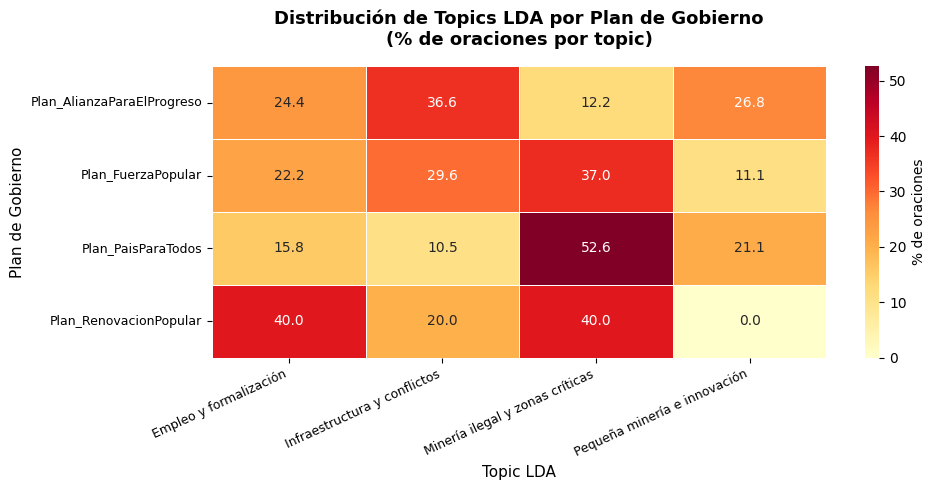

✅ Guardado: lda_heatmap.png


In [ ]:
# definimos topic labels que resuman  el contenido de LDA

TOPIC_LABELS = {
    -1: "Sin topic",
    0: "Empleo y formalización",
    1: "Pequeña minería e innovación",
    2: "Minería ilegal y zonas críticas",
    3: "Infraestructura y conflictos",
}


df["lda_label"] = df["lda_topic_id"].map(TOPIC_LABELS)
df_filtrado = df[df["lda_topic_id"] != -1].copy()


#
# ___ HEATMAP SIMPLE: PLAN × TOPIC LDA ________________________________________

TOPIC_LABELS = {
    -1: "Sin topic",
    0: "Empleo y formalización",
    1: "Pequeña minería e innovación",
    2: "Minería ilegal y zonas críticas",
    3: "Infraestructura y conflictos",
}

df["lda_label"] = df["lda_topic_id"].map(TOPIC_LABELS)

tabla_lda = pd.crosstab(
    df[df["lda_topic_id"] != -1]["plan"],
    df[df["lda_topic_id"] != -1]["lda_label"],
    normalize="index"
).round(3) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    tabla_lda,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% de oraciones"},
)
ax.set_title("Distribución de Topics LDA por Plan de Gobierno\n(% de oraciones por topic)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Topic LDA", fontsize=11)
ax.set_ylabel("Plan de Gobierno", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("lda_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: lda_heatmap.png")

## 5. Zero-Shot Classification — Etiquetado Semántico


In [ ]:
# ___ ETIQUETAS TEMÁTICAS BASADAS EN LDA + CONTEXTO MINERÍA ILEGAL PERÚ _______

ETIQUETAS_TEMATICAS = [
    # __ Desde LDA __________________________
    "formalización minera",
    "exploración y modernización minera",
    "minería ilegal y conflictos sociales",
    "inversión y tributación minera",
    "competitividad minera",
    "gran minería e infraestructura",

    # __ Actualidad: minería ilegal Perú ____
    "impacto ambiental y remediación",
    "crimen organizado y lavado de activos",
    "violencia en zonas mineras",
    "deforestación y contaminación por mercurio",
    "interdicción de minería ilegal",
    "comunidades indígenas y territorio",
    "gobernanza e institucionalidad",
]

In [ ]:

# ___ CARGAR MODELO ZERO-SHOT __________________________________________________
print(f"\n⏳ Cargando modelo zero-shot: {CONFIG['zs_model']}")
zs_classifier = pipeline(
    "zero-shot-classification",
    model=CONFIG["zs_model"],
    device=-1,  # -1 = CPU | 0 = GPU (si disponible)
)
print("✅ Modelo zero-shot cargado")

# %%
# ___ CLASIFICAR ORACIONES CON ZERO-SHOT ______________________________________
print(f"\n⏳ Clasificando {len(df)} oraciones con Zero-Shot...")
oraciones_lista = df["oracion"].tolist()
resultados_zs = []



⏳ Cargando modelo zero-shot: facebook/bart-large-mnli


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 5070.94it/s]


✅ Modelo zero-shot cargado

⏳ Clasificando 97 oraciones con Zero-Shot...


In [ ]:
# Procesamiento en batches para eficiencia
batch_size = CONFIG["zs_batch_size"]
for i in range(0, len(oraciones_lista), batch_size):
    batch = oraciones_lista[i:i + batch_size]
    resultados_batch = zs_classifier(
        batch,
        candidate_labels=ETIQUETAS_TEMATICAS,
        multi_label=False,  # True si una oración puede pertenecer a múltiples temas
    )
    # Si batch_size=1, el resultado no es lista
    if isinstance(resultados_batch, dict):
        resultados_batch = [resultados_batch]
    resultados_zs.extend(resultados_batch)

    if (i // batch_size + 1) % 5 == 0:
        print(f"   Procesadas {min(i + batch_size, len(oraciones_lista))}/{len(oraciones_lista)} oraciones")

# Extraer etiqueta ganadora y su score
df["zs_label"] = [r["labels"][0] for r in resultados_zs]
df["zs_score"] = [r["scores"][0] for r in resultados_zs]


   Procesadas 40/97 oraciones
   Procesadas 80/97 oraciones


In [ ]:
# Guardar distribución completa de scores por etiqueta
for etiqueta in ETIQUETAS_TEMATICAS:
    col_name = f"zs_score_{etiqueta[:20].replace(' ', '_')}"
    df[col_name] = [
        r["scores"][r["labels"].index(etiqueta)] if etiqueta in r["labels"] else 0.0
        for r in resultados_zs
    ]

print("\n✅ Clasificación Zero-Shot completada")
print(f"\nDistribución de etiquetas asignadas:")
print(df["zs_label"].value_counts().to_string())


✅ Clasificación Zero-Shot completada

Distribución de etiquetas asignadas:
zs_label
impacto ambiental y remediación          26
formalización minera                     17
exploración y modernización minera       11
inversión y tributación minera           11
gobernanza e institucionalidad            9
competitividad minera                     8
interdicción de minería ilegal            5
comunidades indígenas y territorio        3
gran minería e infraestructura            2
violencia en zonas mineras                2
minería ilegal y conflictos sociales      2
crimen organizado y lavado de activos     1


## 6. TF-IDF — Relevancia de Palabras por Plan y Tema

In [ ]:
df["tokens_lemma"] = df["tokens_lemma"].apply(lambda x: " ".join(x))

In [ ]:
# ___ TF-IDF POR PLAN DE GOBIERNO _____________________________________________
# Agrupamos todas las oraciones de cada plan en un único "mega-documento"
df_por_plan = df.groupby("plan")["tokens_lemma"].apply(" ".join).reset_index()
df_por_plan.columns = ["plan", "documento_completo"]

# Vectorizar con TF-IDF
vectorizador_plan = TfidfVectorizer(
    max_features=CONFIG["tfidf_max_features"],
    ngram_range=CONFIG["tfidf_ngram_range"],
    min_df=CONFIG["tfidf_min_df"],
    sublinear_tf=True,  # Suavizado logarítmico del TF
)

matriz_tfidf_plan = vectorizador_plan.fit_transform(df_por_plan["documento_completo"])
vocabulario_plan = vectorizador_plan.get_feature_names_out()

In [ ]:
# DataFrame TF-IDF por plan
df_tfidf_plan = pd.DataFrame(
    matriz_tfidf_plan.toarray(),
    index=df_por_plan["plan"],
    columns=vocabulario_plan,
)

print(f"✅ TF-IDF por Plan | Forma: {df_tfidf_plan.shape}")
print(f"   {df_tfidf_plan.shape[0]} planes × {df_tfidf_plan.shape[1]} términos")

✅ TF-IDF por Plan | Forma: (4, 166)
   4 planes × 166 términos


In [ ]:
# ___ TF-IDF POR TEMA (ZERO-SHOT LABEL) ________________________________________
df_por_tema = df.groupby("zs_label")["tokens_lemma"].apply(" ".join).reset_index()
df_por_tema.columns = ["tema", "documento_completo"]

vectorizador_tema = TfidfVectorizer(
    max_features=CONFIG["tfidf_max_features"],
    ngram_range=CONFIG["tfidf_ngram_range"],
    min_df=1,
    sublinear_tf=True,
)


matriz_tfidf_tema = vectorizador_tema.fit_transform(df_por_tema["documento_completo"])
vocabulario_tema = vectorizador_tema.get_feature_names_out()

df_tfidf_tema = pd.DataFrame(
    matriz_tfidf_tema.toarray(),
    index=df_por_tema["tema"],
    columns=vocabulario_tema,
)

print(f"✅ TF-IDF por Tema Zero-Shot | Forma: {df_tfidf_tema.shape}")

✅ TF-IDF por Tema Zero-Shot | Forma: (12, 1488)


In [ ]:
# ___ TOP PALABRAS POR PLAN ____________________________________________________
def top_palabras_por_documento(df_tfidf, n=15):
    """Retorna las N palabras con mayor TF-IDF para cada documento (fila)."""
    resultado = {}
    for doc in df_tfidf.index:
        serie = df_tfidf.loc[doc].sort_values(ascending=False)
        resultado[doc] = list(zip(serie.index[:n], serie.values[:n].round(4)))
    return resultado


top_por_plan = top_palabras_por_documento(df_tfidf_plan, n=15)
top_por_tema = top_palabras_por_documento(df_tfidf_tema, n=15)

print("\n📋 TOP 10 PALABRAS MÁS RELEVANTES POR PLAN (TF-IDF):")
print("=" * 60)
for plan, palabras in top_por_plan.items():
    print(f"\n🏛️  {plan}:")
    print("   " + " | ".join([f"{p} ({s})" for p, s in palabras[:10]]))


📋 TOP 10 PALABRAS MÁS RELEVANTES POR PLAN (TF-IDF):

🏛️  Plan_AlianzaParaElProgreso:
   empleo (0.1572) | formalización (0.1572) | tecnológico (0.1438) | local (0.1438) | formalizado (0.1438) | desarrollo (0.1362) | productivo (0.1362) | minero (0.1317) | mineer (0.1275) | gran (0.1273)

🏛️  Plan_FuerzaPopular:
   crítico (0.1661) | proyecto (0.1661) | operación (0.1519) | reducir (0.1519) | corredor (0.1519) | minero (0.1468) | ambiental (0.1439) | mineer (0.1347) | pequeño (0.1345) | mineer artesanal (0.1336)

🏛️  Plan_PaisParaTodos:
   minero (0.1846) | formalización (0.1831) | ilegal (0.1685) | exploración (0.1482) | mineer ilegal (0.1482) | mercado (0.1482) | formalizado (0.1477) | fortalecer (0.1477) | trazabilidad (0.1477) | régimen (0.1477)

🏛️  Plan_RenovacionPopular:
   ambiente (0.2959) | medio ambiente (0.2959) | modernización (0.2959) | medio (0.2959) | mineer (0.2428) | aquel (0.1748) | participación (0.1748) | permitir (0.1748) | tecnologío (0.1748) | generación (0.1748

In [ ]:

# ___ DISTRIBUCIÓN DE TEMAS POR PLAN __________________________________________
tabla_orientacion = pd.crosstab(
    df["plan"],
    df["zs_label"],
    normalize="index",  # Proporciones por fila (por plan)
).round(3) * 100  # En porcentaje

print("📊 ORIENTACIÓN TEMÁTICA POR PLAN (% de oraciones por tema):")
print(tabla_orientacion.to_string())

# %%
# ___ SCORE PROMEDIO POR TEMA Y PLAN __________________________________________
# Mide no solo la frecuencia sino la "confianza" del zero-shot
tabla_score = df.groupby(["plan", "zs_label"])["zs_score"].mean().unstack(fill_value=0).round(3)

print("\n📊 SCORE PROMEDIO ZERO-SHOT POR PLAN Y TEMA:")
print(tabla_score.to_string())


📊 ORIENTACIÓN TEMÁTICA POR PLAN (% de oraciones por tema):
zs_label                    competitividad minera  comunidades indígenas y territorio  crimen organizado y lavado de activos  exploración y modernización minera  formalización minera  gobernanza e institucionalidad  gran minería e infraestructura  impacto ambiental y remediación  interdicción de minería ilegal  inversión y tributación minera  minería ilegal y conflictos sociales  violencia en zonas mineras
plan                                                                                                                                                                                                                                                                                                                                                                                                                     
Plan_AlianzaParaElProgreso                   11.6                                 4.7                                    

## 8. Visualizaciones

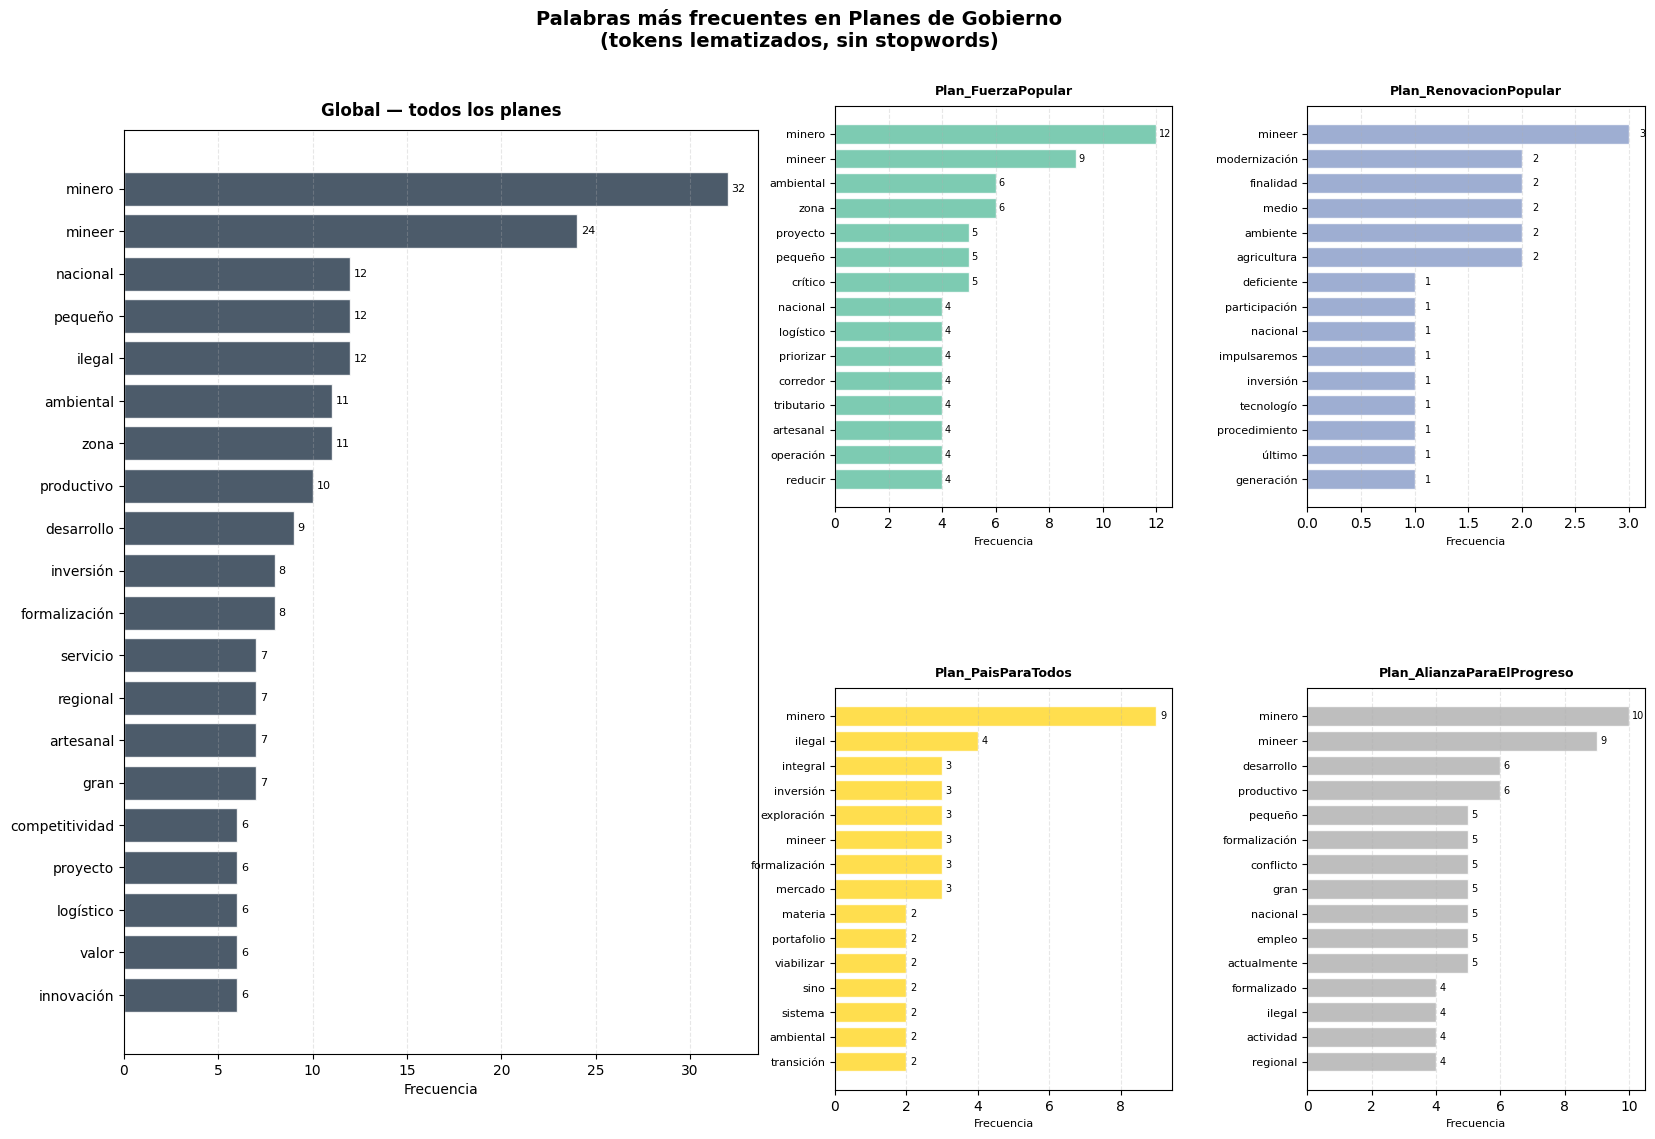

✅ Guardado: frecuencia_palabras.png


In [ ]:
# ___ FIGURA: GLOBAL (mitad) + 4 PLANES (2x2) _________________________________
from collections import Counter

todos_tokens = [token for lista in df["tokens_lemma"] for token in lista]
frecuencia_global = Counter(todos_tokens).most_common(20)
palabras_g, conteos_g = zip(*frecuencia_global)

planes = df["plan"].unique()
freq_por_plan = {}
for plan in planes:
    tokens_plan = [t for lista in df[df["plan"] == plan]["tokens_lemma"] for t in lista]
    freq_por_plan[plan] = Counter(tokens_plan).most_common(15)

colores_planes = plt.cm.Set2(np.linspace(0, 1, len(planes)))

# Layout: 2 columnas
# Columna izquierda  → global ocupa las 2 filas (subplot grande)
# Columna derecha    → 2x2 con los 4 planes
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Palabras más frecuentes en Planes de Gobierno\n(tokens lematizados, sin stopwords)",
             fontsize=14, fontweight="bold")

# __ Global: columna izquierda, ocupa fila 1 y 2 ______________________________
ax_global = fig.add_subplot(1, 2, 1)
ax_global.barh(palabras_g, conteos_g, color="#2c3e50", alpha=0.85, edgecolor="white")
ax_global.invert_yaxis()
ax_global.set_title("Global — todos los planes", fontsize=12, fontweight="bold", pad=10)
ax_global.set_xlabel("Frecuencia")
ax_global.grid(axis="x", alpha=0.3, linestyle="--")
for i, v in enumerate(conteos_g):
    ax_global.text(v + 0.2, i, str(v), va="center", fontsize=8)

# __ 4 planes: columna derecha en grilla 2x2 ___________________________________
posiciones = [221, 222, 223, 224]  # subplot codes para grilla 2x2 en lado derecho

# Usamos GridSpec para tener control fino
from matplotlib.gridspec import GridSpec

gs = GridSpec(2, 2, figure=fig,
              left=0.52,   # empieza después de la mitad
              right=0.97,
              top=0.90,
              bottom=0.08,
              hspace=0.45,
              wspace=0.4)

for idx, (plan, color) in enumerate(zip(planes[:4], colores_planes)):
    fila = idx // 2
    col  = idx % 2
    ax = fig.add_subplot(gs[fila, col])

    palabras_p, conteos_p = zip(*freq_por_plan[plan])
    ax.barh(palabras_p, conteos_p, color=color, alpha=0.85, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(plan, fontsize=9, fontweight="bold", pad=8)
    ax.set_xlabel("Frecuencia", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    for i, v in enumerate(conteos_p):
        ax.text(v + 0.1, i, str(v), va="center", fontsize=7)


plt.savefig("frecuencia_palabras.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: frecuencia_palabras.png")


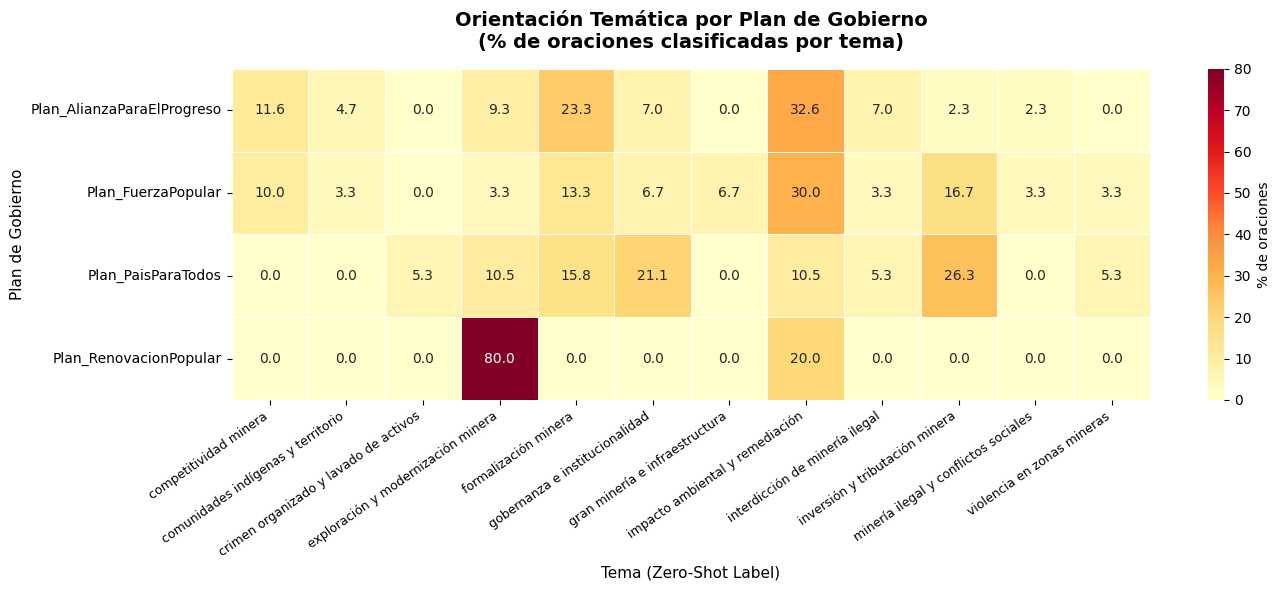

✅ Guardado: orientacion_tematica_heatmap.png


In [ ]:
# ___ FIGURA 2: HEATMAP DE ORIENTACIÓN TEMÁTICA ________________________________
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    tabla_orientacion,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% de oraciones"},
)
ax.set_title("Orientación Temática por Plan de Gobierno\n(% de oraciones clasificadas por tema)", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tema (Zero-Shot Label)", fontsize=11)
ax.set_ylabel("Plan de Gobierno", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("orientacion_tematica_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: orientacion_tematica_heatmap.png")

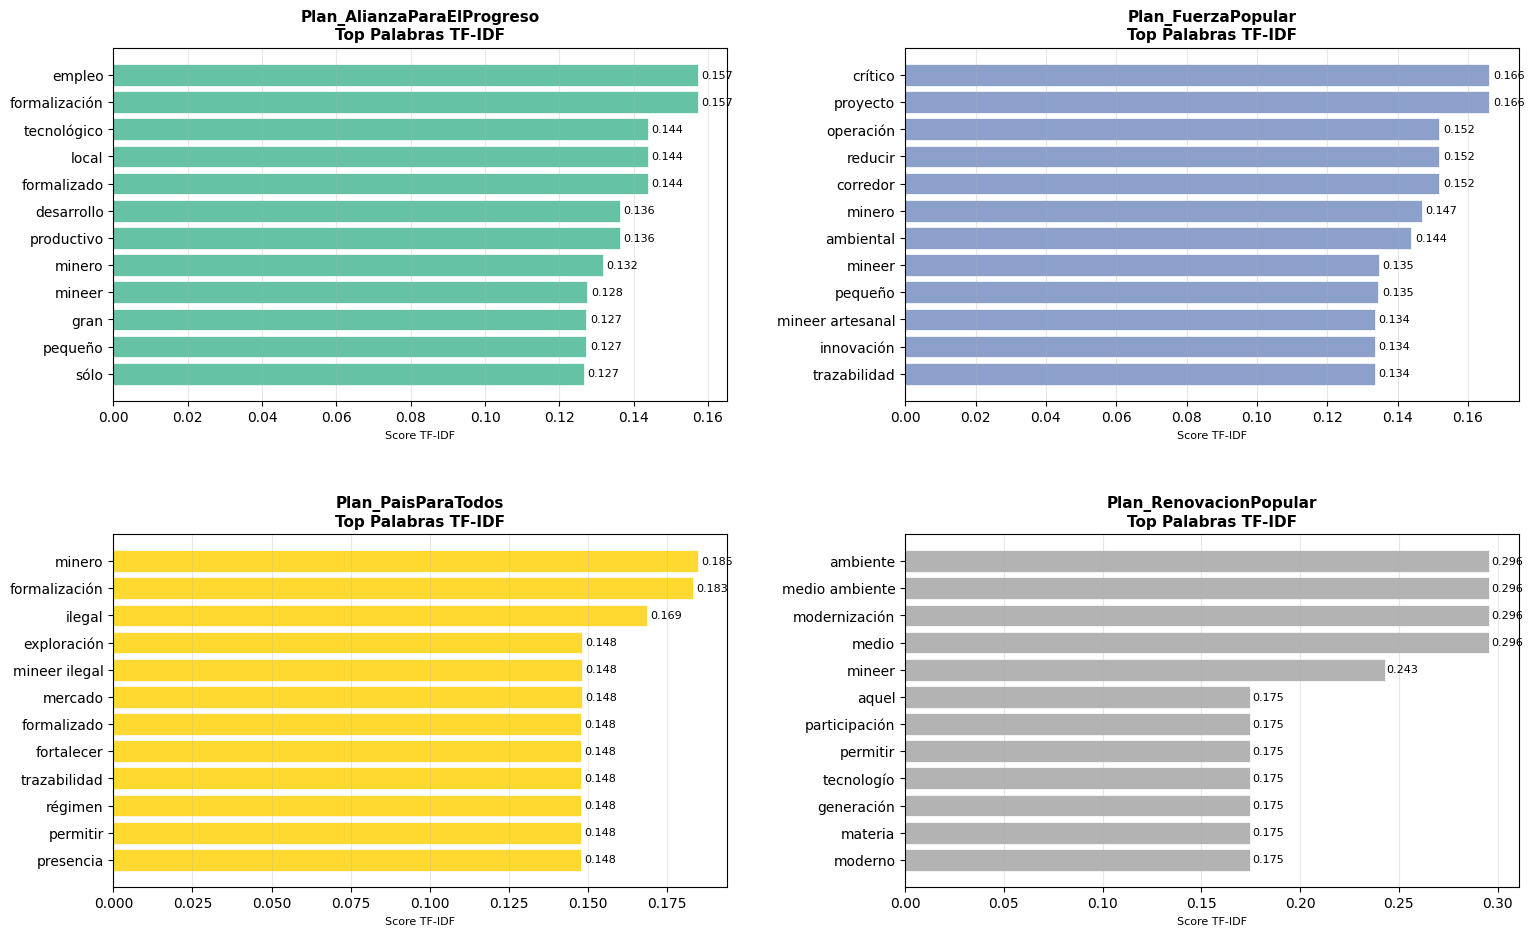

✅ Guardado: tf-idf.png


In [ ]:
# ___ FIGURA 3: TOP TF-IDF POR PLAN ____________________________________________
planes = df_por_plan["plan"].tolist()
n_planes = len(planes)
n_cols = 2
n_rows = (n_planes + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten() if n_planes > 1 else [axes]

colores = plt.cm.Set2(np.linspace(0, 1, n_planes))

for idx, (plan, color) in enumerate(zip(planes, colores)):
    ax = axes[idx]
    palabras, scores = zip(*top_por_plan[plan][:12])
    y_pos = np.arange(len(palabras))
    bars = ax.barh(y_pos, scores, color=color, edgecolor="white", linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(palabras, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f"{plan}\nTop Palabras TF-IDF", fontsize=11, fontweight="bold")
    ax.set_xlabel("Score TF-IDF", fontsize=8)
    ax.grid(axis="x", alpha=0.3)
    # Añadir valores
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va="center", fontsize=8)
plt.tight_layout(pad=3.0, h_pad=4.0) 
plt.savefig("tf-idf.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: tf-idf.png")

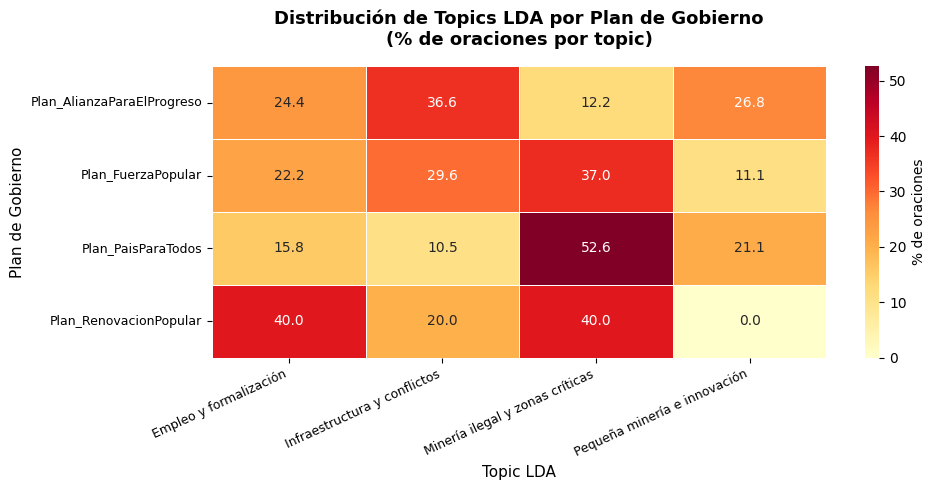

✅ Guardado: lda_heatmap.png


In [ ]:
# definimos topic labels que resuman  el contenido de LDA

TOPIC_LABELS = {
    -1: "Sin topic",
    0: "Empleo y formalización",
    1: "Pequeña minería e innovación",
    2: "Minería ilegal y zonas críticas",
    3: "Infraestructura y conflictos",
}


df["lda_label"] = df["lda_topic_id"].map(TOPIC_LABELS)
df_filtrado = df[df["lda_topic_id"] != -1].copy()


#
# ___ HEATMAP SIMPLE: PLAN × TOPIC LDA ________________________________________

TOPIC_LABELS = {
    -1: "Sin topic",
    0: "Empleo y formalización",
    1: "Pequeña minería e innovación",
    2: "Minería ilegal y zonas críticas",
    3: "Infraestructura y conflictos",
}

df["lda_label"] = df["lda_topic_id"].map(TOPIC_LABELS)

tabla_lda = pd.crosstab(
    df[df["lda_topic_id"] != -1]["plan"],
    df[df["lda_topic_id"] != -1]["lda_label"],
    normalize="index"
).round(3) * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    tabla_lda,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% de oraciones"},
)
ax.set_title("Distribución de Topics LDA por Plan de Gobierno\n(% de oraciones por topic)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Topic LDA", fontsize=11)
ax.set_ylabel("Plan de Gobierno", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("lda_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: lda_heatmap.png")

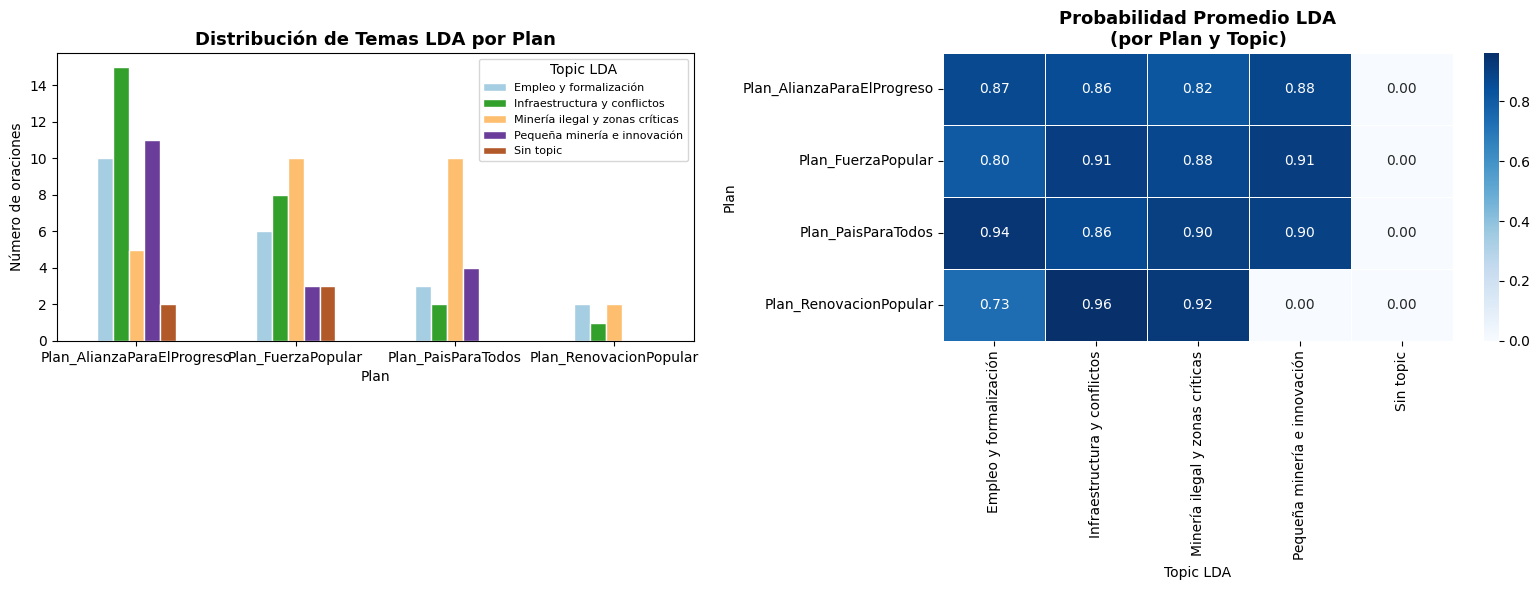

✅ Guardado: distribucion_lda.png


In [ ]:
# ___ FIGURA 4: DISTRIBUCIÓN LDA TOPICS ________________________________________
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4a: Conteo por tema LDA
conteo_lda = df.groupby(["plan", "lda_label"]).size().unstack(fill_value=0)
conteo_lda.plot(kind="bar", ax=axes[0], colormap="Paired", edgecolor="white")
axes[0].set_title("Distribución de Temas LDA por Plan", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Plan")
axes[0].set_ylabel("Número de oraciones")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Topic LDA", fontsize=8)

# 4b: Probabilidad promedio por tema LDA
prob_lda = df.groupby(["plan", "lda_label"])["lda_prob"].mean().unstack(fill_value=0)
sns.heatmap(prob_lda, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], linewidths=0.5)
axes[1].set_title("Probabilidad Promedio LDA\n(por Plan y Topic)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Topic LDA")
axes[1].set_ylabel("Plan")

plt.tight_layout()
plt.savefig("distribucion_lda.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Guardado: distribucion_lda.png")